In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

# Set the working directorty
working_dir = r"C:/Users/valentin.stuhlfauth/OneDrive - univ-lyon2.fr/1_WSL/1_SGR visuals/git_repo_sgr_visuals"
os.chdir(working_dir)

import plot_functions
print(plot_functions.__file__)

# Set font
plt.rcParams['font.family'] = 'Arial'

c:\Users\valentin.stuhlfauth\OneDrive - univ-lyon2.fr\1_WSL\1_SGR visuals\git_repo_sgr_visuals\plot_functions.py


All libraries imported successfully!
Loading datasets...
Loaded biofuels_cons.csv: 945 rows
Loaded biofuels_exports.csv: 151470 rows
Loaded biofuels_imports.csv: 151470 rows
Loaded electricity_cons.csv: 945 rows
Loaded electricity_exports.csv: 0 rows
Loaded electricity_imports.csv: 151470 rows
Loaded heat_cons.csv: 945 rows
Loaded heat_exports.csv: 151470 rows
Loaded heat_imports.csv: 151470 rows
Loaded natural_gas_cons.csv: 945 rows
Loaded natural_gas_exports.csv: 605880 rows
Loaded natural_gas_imports.csv: 151470 rows
Loaded oil_petroleum_products_cons.csv: 945 rows
Loaded oil_petroleum_products_exports.csv: 151470 rows
Loaded oil_petroleum_products_imports.csv: 151470 rows
Loaded solid_fossil_fuels_cons.csv: 945 rows
Loaded solid_fossil_fuels_exports.csv: 151470 rows
Loaded solid_fossil_fuels_imports.csv: 151470 rows

Found energy sources: ['biofuels', 'electricity', 'heat', 'natural_gas', 'oil_petroleum_products', 'solid_fossil_fuels']

=== EU-SCALE ANALYSIS ===
1. Plotting EU ener

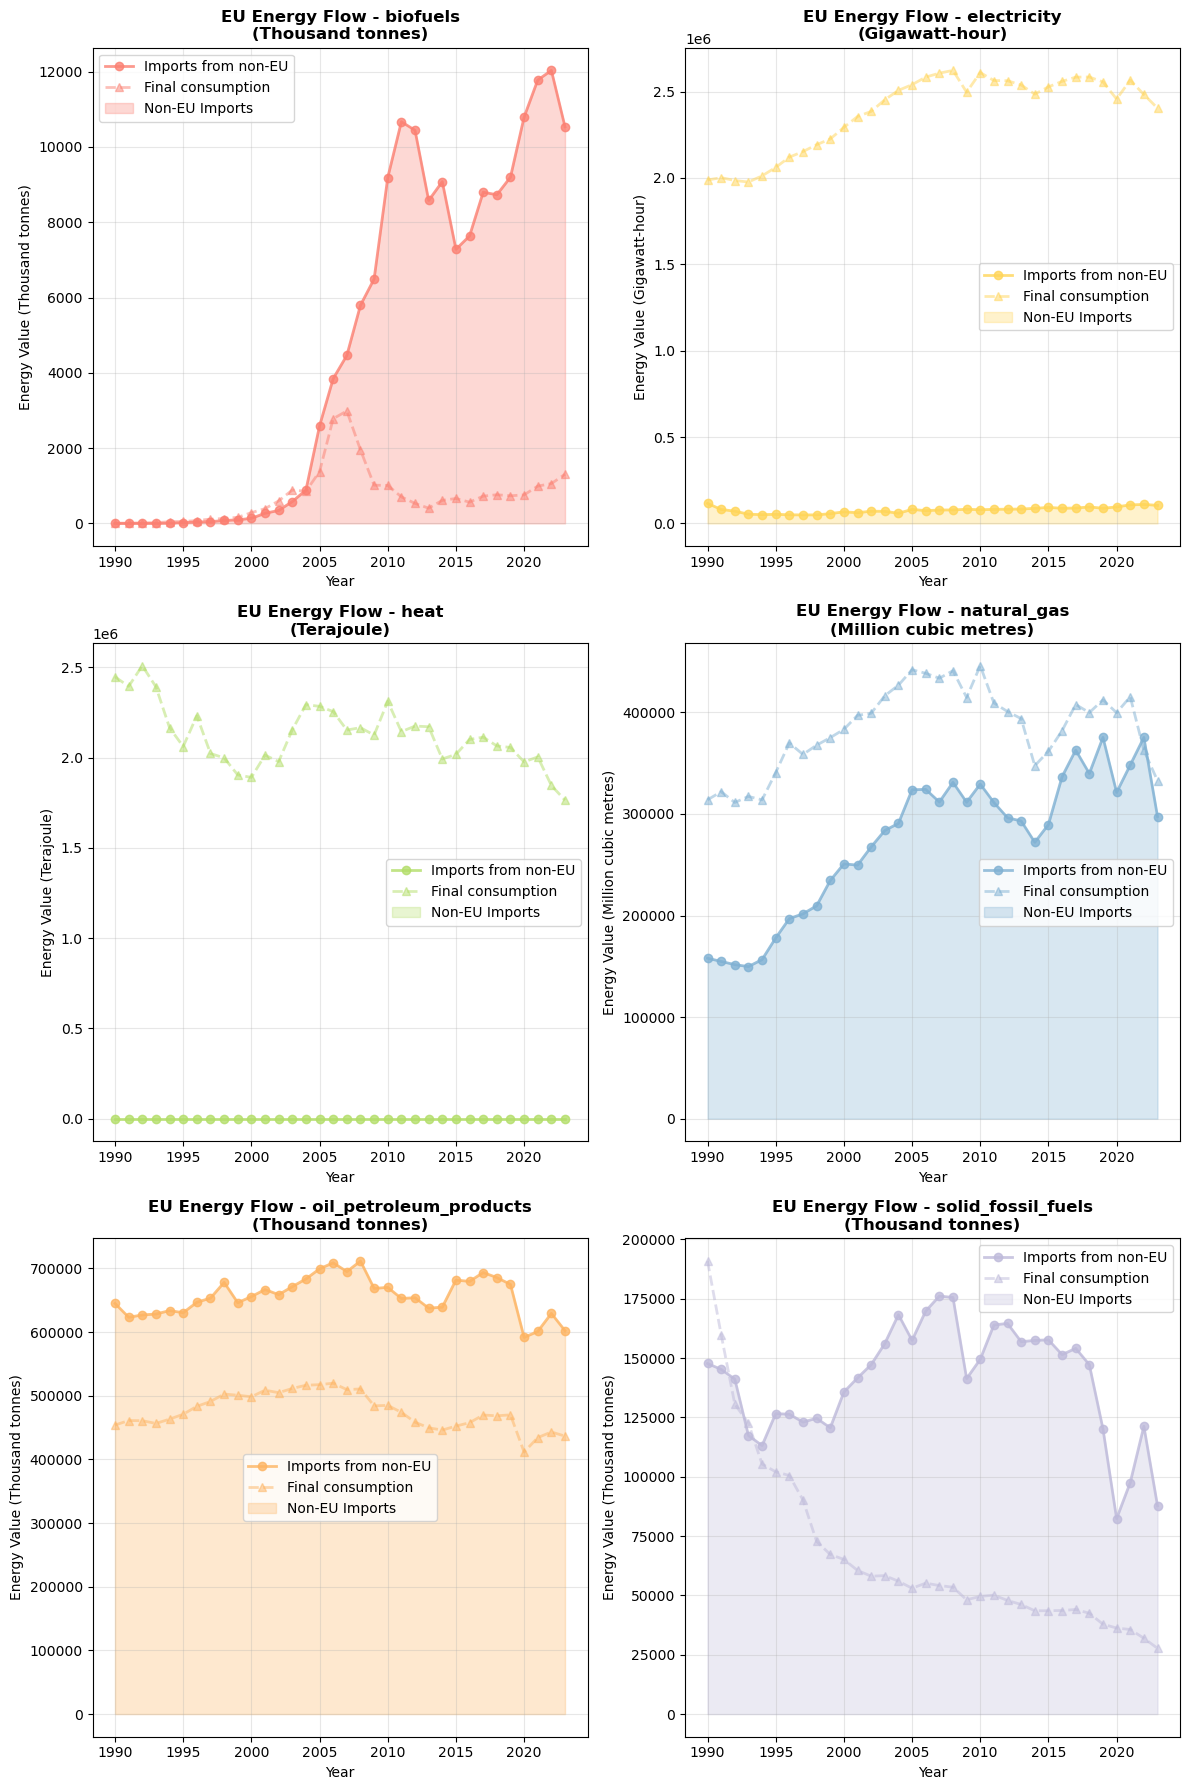

2. Plotting top suppliers to EU...


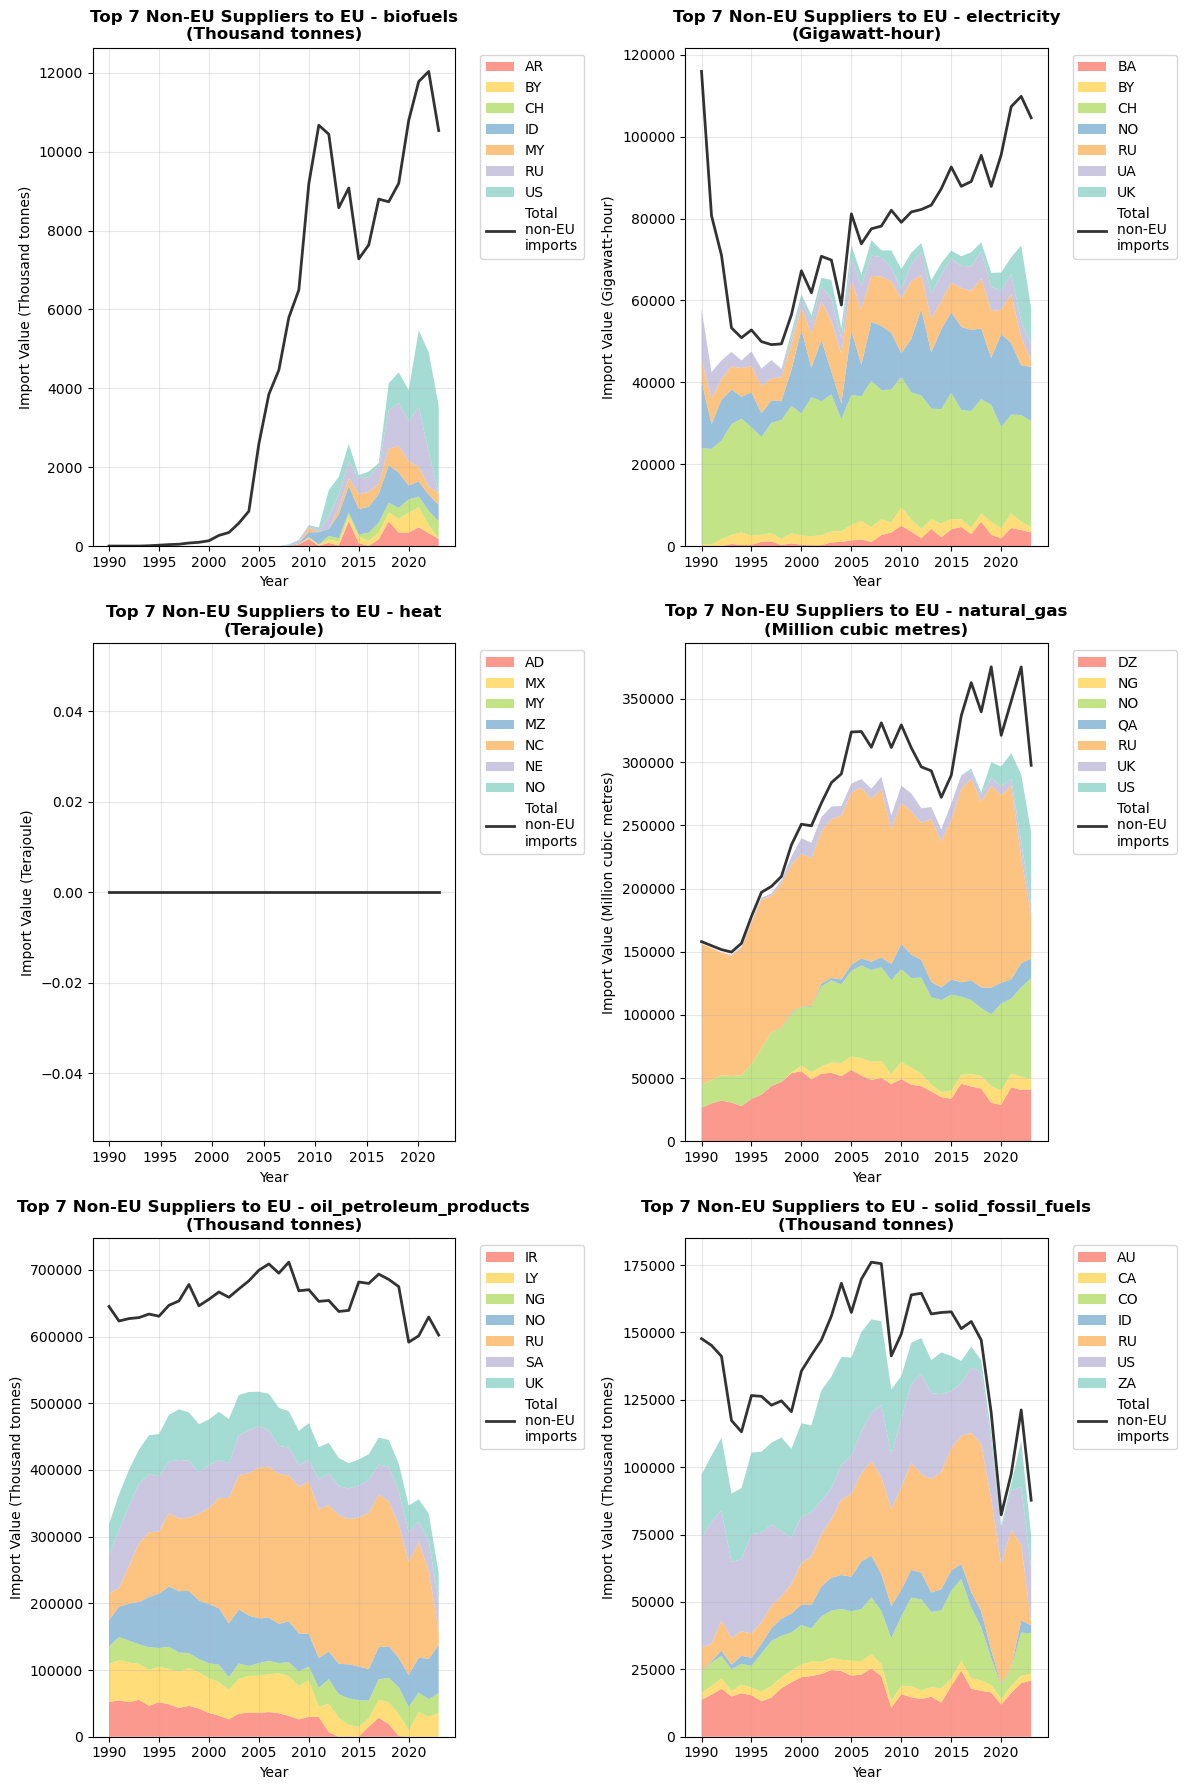


Analysis complete! Check the generated PNG files for visualizations.


In [2]:
# Import all required libraries
try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import glob
    import os
    from pathlib import Path
    import warnings
    warnings.filterwarnings('ignore')
    print("All libraries imported successfully!")
except ImportError as e:
    print(f"Import error: {e}")
    print("Please install missing libraries with: pip install pandas numpy matplotlib seaborn")

# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

class EnergyFlowAnalyzer:
    def __init__(self, data_path, eu27_countries):
        self.data_path = data_path
        self.eu27_countries = eu27_countries
        self.countries = eu27_countries + ['EU27_2020']  # Add EU to the list
        self.datasets = {}
        self.energy_sources = []
        self.colors = ['#fb8072', '#ffd558', '#b3de69', '#80b1d3', '#fdb462', '#bebada', '#8dd3c7','#ffffb3']
        self.units = {
            'biofuels': 'Thousand tonnes',
            'electricity': 'Gigawatt-hour', 
            'heat': 'Terajoule',
            'natural_gas': 'Million cubic metres',
            'oil_petroleum_products': 'Thousand tonnes',
            'solid_fossil_fuels': 'Thousand tonnes'
        }
        
    def load_datasets(self):
        """Load all CSV files from the specified directory"""
        csv_files = glob.glob(os.path.join(self.data_path, "*.csv"))
        
        for file_path in csv_files:
            filename = os.path.basename(file_path)
            parts = filename.replace('.csv', '').split('_')
            
            if len(parts) < 2:
                continue
                
            # Extract energy source and data type
            energy_source = '_'.join(parts[:-1])  # Everything except the last part
            data_type = parts[-1]  # Last part (cons, imports, exports)
            
            if energy_source not in self.datasets:
                self.datasets[energy_source] = {}
                
            try:
                df = pd.read_csv(file_path)
                # Filter for relevant countries
                df_filtered = df[df['geo'].isin(self.countries)]
                self.datasets[energy_source][data_type] = df_filtered
                
                if energy_source not in self.energy_sources:
                    self.energy_sources.append(energy_source)
                    
                print(f"Loaded {filename}: {len(df_filtered)} rows")
                
            except Exception as e:
                print(f"Error loading {filename}: {str(e)}")
        
        print(f"\nFound energy sources: {self.energy_sources}")
        return self.datasets
    
    def calculate_eu_energy_dependency(self):
        """Calculate energy dependency for EU: Imports from non-EU / Final consumption"""
        eu_dependencies = {}
        
        for source in self.energy_sources:
            if all(dtype in self.datasets[source] for dtype in ['imports', 'cons']):
                # Get EU imports from non-EU countries only (excluding TOTAL)
                imports_eu = self.datasets[source]['imports'][
                    (self.datasets[source]['imports']['geo'] == 'EU27_2020') &
                    (~self.datasets[source]['imports']['partner'].isin(self.eu27_countries + ['EU27_2020', 'TOTAL']))
                ].groupby('year')['value'].sum().reset_index()
                
                # Get EU consumption
                cons_eu = self.datasets[source]['cons'][
                    self.datasets[source]['cons']['geo'] == 'EU27_2020'
                ].copy()
                
                if len(imports_eu) == 0 and len(cons_eu) == 0:
                    print(f"Warning: No data for {source} EU dependency calculation")
                    continue
                elif len(imports_eu) == 0:
                    # Create empty imports data for years where consumption exists
                    imports_eu = pd.DataFrame({
                        'year': cons_eu['year'].unique(),
                        'value': 0
                    })
                
                # Merge data
                merged = imports_eu.merge(cons_eu[['year', 'value']], on='year', how='outer')
                merged = merged.fillna(0)
                merged = merged.rename(columns={
                    'value_x': 'imports_non_eu',
                    'value_y': 'consumption'
                })
                
                # Calculate dependency as imports from outside EU / consumption
                merged['dependency'] = np.where(merged['consumption'] != 0,
                                              merged['imports_non_eu'] / merged['consumption'], 0)
                
                eu_dependencies[source] = merged
                
        return eu_dependencies
    
    def plot_eu_energy_flows(self):
        """Visualize EU energy flows for each source in 3x2 format"""
        n_sources = len(self.energy_sources)
        n_cols = 2  # Changed from 3 to 2
        n_rows = 3  # Changed from calculated to fixed 3
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 18))  # Adjusted figure size
        axes = axes.flatten()
        
        eu_deps = self.calculate_eu_energy_dependency()
        
        for i, source in enumerate(self.energy_sources):
            ax = axes[i]
            color = self.colors[i % len(self.colors)]
            unit = self.units.get(source, 'Units')
            
            if source in eu_deps:
                data = eu_deps[source]
                
                # Filter out the last year if it has 0 values
                if len(data) > 1:
                    last_year = data['year'].max()
                    last_year_data = data[data['year'] == last_year]
                    if (last_year_data['imports_non_eu'].iloc[0] == 0 and 
                        last_year_data['consumption'].iloc[0] == 0):
                        data = data[data['year'] != last_year]
                
                # Plot imports from non-EU and consumption
                ax.plot(data['year'], data['imports_non_eu'], label='Imports from non-EU', 
                       marker='o', linewidth=2, color=color, alpha=0.8)
                ax.plot(data['year'], data['consumption'], label='Final consumption', 
                       marker='^', linewidth=2, color=color, alpha=0.5, linestyle='--')
                ax.fill_between(data['year'], data['imports_non_eu'], alpha=0.3, 
                               color=color, label='Non-EU Imports')
                
                ax.set_title(f'EU Energy Flow - {source}\n({unit})', fontsize=12, fontweight='bold')
                ax.set_xlabel('Year')
                ax.set_ylabel(f'Energy Value ({unit})')
                ax.legend()
                ax.grid(True, alpha=0.3)
            else:
                ax.text(0.5, 0.5, f'No data available\nfor {source}', 
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'EU Energy Flow - {source}', fontsize=12, fontweight='bold')
        
        # Hide unused subplots
        for j in range(n_sources, len(axes)):
            axes[j].set_visible(False)
            
        plt.tight_layout()
        plt.savefig('eu_energy_flows.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def plot_eu_top_suppliers(self, top_n=7):
        """Plot top non-EU suppliers for each energy source to EU in 3x2 format, excluding NSP from colors"""
        n_sources = len(self.energy_sources)
        n_cols = 2  # Changed from 3 to 2
        n_rows = 3  # Changed from calculated to fixed 3
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 18))  # Adjusted figure size
        axes = axes.flatten()
        
        for i, source in enumerate(self.energy_sources):
            ax = axes[i]
            unit = self.units.get(source, 'Units')
            
            if 'imports' not in self.datasets[source]:
                ax.text(0.5, 0.5, f'No import data\nfor {source}', 
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'Top {top_n} Non-EU Suppliers to EU - {source}', fontsize=12, fontweight='bold')
                continue
                
            # Get EU imports from non-EU countries only (excluding TOTAL)
            eu_imports = self.datasets[source]['imports'][
                (self.datasets[source]['imports']['geo'] == 'EU27_2020') &
                (~self.datasets[source]['imports']['partner'].isin(self.eu27_countries + ['EU27_2020', 'TOTAL']))
            ]
            
            if len(eu_imports) == 0:
                # Special case for heat - no imports expected
                if source == 'heat':
                    ax.text(0.5, 0.5, 'No non-EU imports', 
                           ha='center', va='center', transform=ax.transAxes,
                           fontsize=14, fontweight='bold')
                else:
                    ax.text(0.5, 0.5, f'No non-EU import data\nfor {source}', 
                           ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'Top {top_n} Non-EU Suppliers to EU - {source}', fontsize=12, fontweight='bold')
                continue
            
            # Get top suppliers by total imports (excluding NSP from top suppliers for coloring)
            supplier_totals = eu_imports.groupby('partner')['value'].sum().sort_values(ascending=False)
            
            # Exclude NSP from the top suppliers list for coloring, but keep for total calculation
            supplier_totals_for_colors = supplier_totals[supplier_totals.index != 'NSP']
            top_suppliers_for_colors = supplier_totals_for_colors.head(top_n)
            
            if len(supplier_totals) == 0:
                ax.text(0.5, 0.5, f'No supplier data\nfor {source}', 
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'Top {top_n} Non-EU Suppliers to EU - {source}', fontsize=12, fontweight='bold')
                continue
            
            # Create stacked area chart for top suppliers over time (excluding NSP from colors)
            if len(top_suppliers_for_colors) > 0:
                pivot_data = eu_imports[eu_imports['partner'].isin(top_suppliers_for_colors.index)].pivot_table(
                    index='year', columns='partner', values='value', fill_value=0
                )
            else:
                pivot_data = pd.DataFrame()
            
            # Filter out last year if it has 0 values (don't plot if last year is all zeros)
            if len(pivot_data) > 1:
                last_year = pivot_data.index.max()
                if pivot_data.loc[last_year].sum() == 0:
                    pivot_data = pivot_data.drop(last_year)
            
            # Get total imports for EU27_2020 from all non-EU countries (including NSP)
            total_imports_all = eu_imports.groupby('year')['value'].sum()
            
            if len(pivot_data) > 0:
                # Filter total imports to match the years in pivot_data
                total_imports_filtered = total_imports_all[total_imports_all.index.isin(pivot_data.index)]
                
                # Plot stacked area with custom colors (excluding NSP)
                colors_cycle = self.colors * ((len(pivot_data.columns) // len(self.colors)) + 1)
                ax.stackplot(pivot_data.index, *[pivot_data[col] for col in pivot_data.columns], 
                            labels=pivot_data.columns, alpha=0.8, colors=colors_cycle[:len(pivot_data.columns)])
                
                # Add total imports line (including NSP in calculation)
                ax.plot(total_imports_filtered.index, total_imports_filtered.values, 
                       color='black', linewidth=2, linestyle='-', 
                       label='Total \nnon-EU \nimports', alpha=0.8)
                
                ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            else:
                # If no suppliers to color, just show total line
                if len(total_imports_all) > 0:
                    ax.plot(total_imports_all.index, total_imports_all.values, 
                           color='black', linewidth=2, linestyle='-', 
                           label='Total \nnon-EU \nimports', alpha=0.8)
                    ax.legend()
                else:
                    ax.text(0.5, 0.5, f'No valid time series data\nfor {source}', 
                           ha='center', va='center', transform=ax.transAxes)
            
            ax.set_title(f'Top {top_n} Non-EU Suppliers to EU - {source}\n({unit})', 
                        fontsize=12, fontweight='bold')
            ax.set_xlabel('Year')
            ax.set_ylabel(f'Import Value ({unit})')
            ax.grid(True, alpha=0.3)
        
        # Hide unused subplots
        for j in range(n_sources, len(axes)):
            axes[j].set_visible(False)
            
        plt.tight_layout()
        plt.savefig('eu_top_suppliers.png', dpi=300, bbox_inches='tight')
        plt.show()

# Main execution
def main():
    # Define the path and EU27 countries
    data_path = "1_data_prep/indicator_trade_energy"
    eu27_countries = ['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 
                     'FR', 'GR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 
                     'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK']
    
    # Initialize analyzer
    analyzer = EnergyFlowAnalyzer(data_path, eu27_countries)
    
    # Load datasets
    print("Loading datasets...")
    analyzer.load_datasets()
    
    # EU-scale analysis only
    print("\n=== EU-SCALE ANALYSIS ===")
    
    print("1. Plotting EU energy flows...")
    analyzer.plot_eu_energy_flows()
    
    print("2. Plotting top suppliers to EU...")
    analyzer.plot_eu_top_suppliers()
    
    print("\nAnalysis complete! Check the generated PNG files for visualizations.")

if __name__ == "__main__":
    main()

All libraries imported successfully!
Loading datasets...
Loaded biofuels_cons.csv: 945 rows
Loaded biofuels_exports.csv: 151470 rows
Loaded biofuels_imports.csv: 151470 rows
Loaded electricity_cons.csv: 945 rows
Loaded electricity_exports.csv: 0 rows
Loaded electricity_imports.csv: 151470 rows
Loaded heat_cons.csv: 945 rows
Loaded heat_exports.csv: 151470 rows
Loaded heat_imports.csv: 151470 rows
Loaded natural_gas_cons.csv: 945 rows
Loaded natural_gas_exports.csv: 605880 rows
Loaded natural_gas_imports.csv: 151470 rows
Loaded oil_petroleum_products_cons.csv: 945 rows
Loaded oil_petroleum_products_exports.csv: 151470 rows
Loaded oil_petroleum_products_imports.csv: 151470 rows
Loaded solid_fossil_fuels_cons.csv: 945 rows
Loaded solid_fossil_fuels_exports.csv: 151470 rows
Loaded solid_fossil_fuels_imports.csv: 151470 rows

Found energy sources: ['biofuels', 'electricity', 'heat', 'natural_gas', 'oil_petroleum_products', 'solid_fossil_fuels']

=== EU-SCALE ANALYSIS ===
1. Plotting EU ener

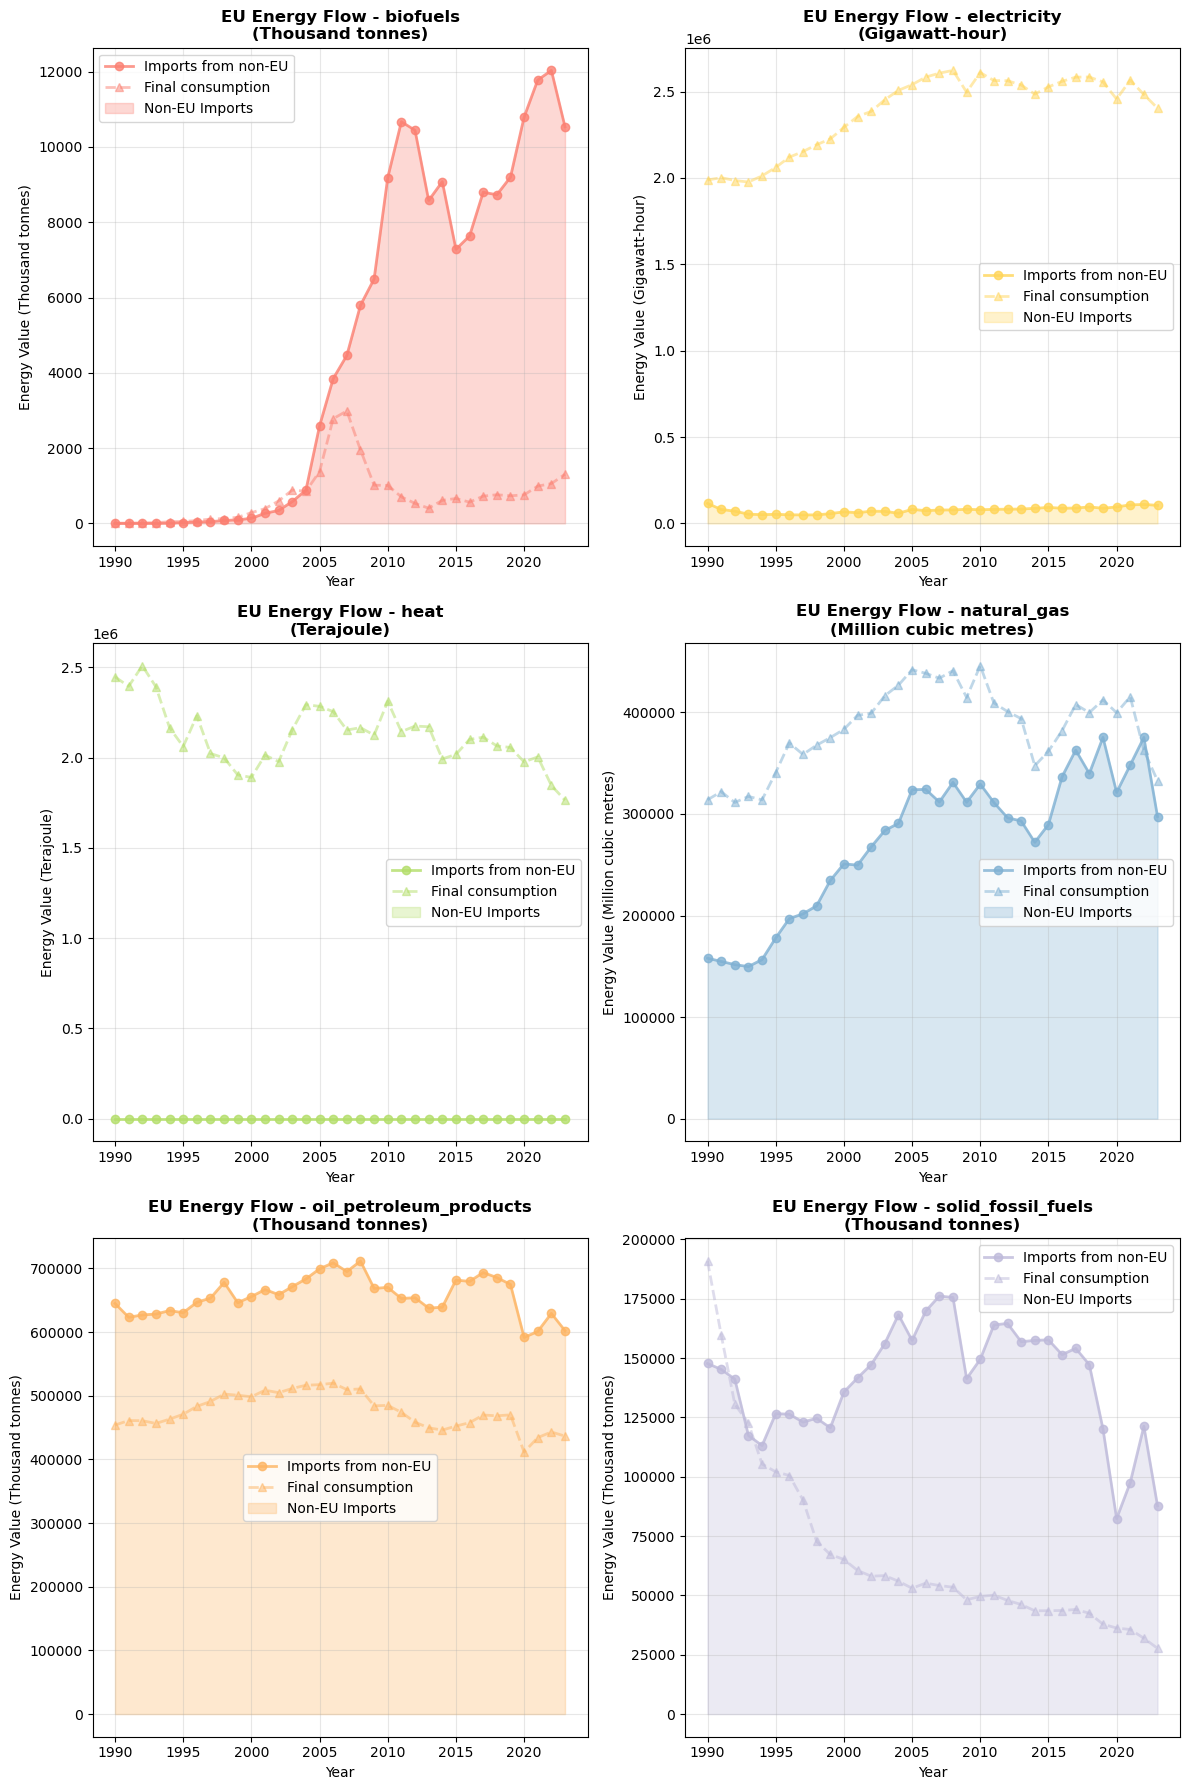

2. Plotting top suppliers to EU...


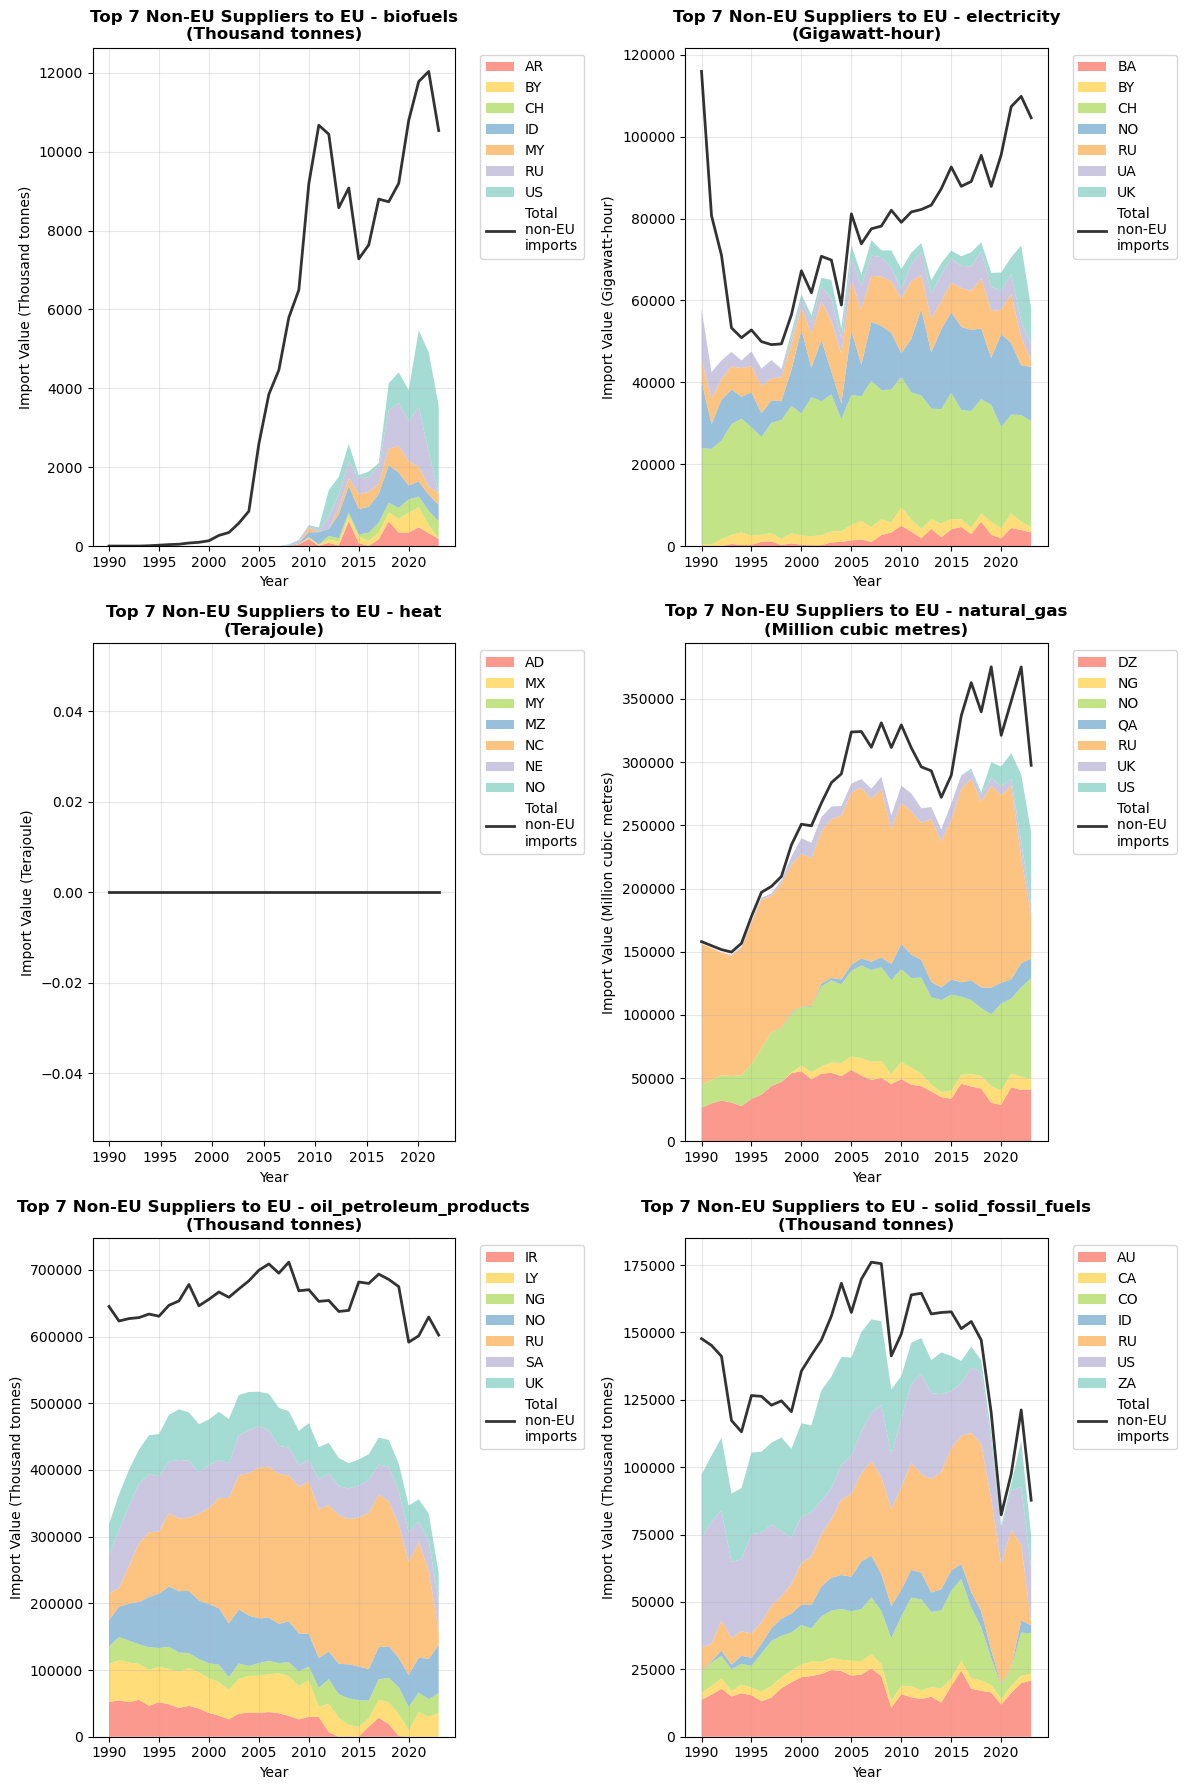


Analysis complete! Check the generated PNG files for visualizations.


In [3]:
# Import all required libraries
try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import glob
    import os
    from pathlib import Path
    import warnings
    warnings.filterwarnings('ignore')
    print("All libraries imported successfully!")
except ImportError as e:
    print(f"Import error: {e}")
    print("Please install missing libraries with: pip install pandas numpy matplotlib seaborn")

# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

class EnergyFlowAnalyzer:
    def __init__(self, data_path, eu27_countries):
        self.data_path = data_path
        self.eu27_countries = eu27_countries
        self.countries = eu27_countries + ['EU27_2020']  # Add EU to the list
        self.datasets = {}
        self.energy_sources = []
        self.colors = ['#fb8072', '#ffd558', '#b3de69', '#80b1d3', '#fdb462', '#bebada', '#8dd3c7','#ffffb3']
        self.units = {
            'biofuels': 'Thousand tonnes',
            'electricity': 'Gigawatt-hour', 
            'heat': 'Terajoule',
            'natural_gas': 'Million cubic metres',
            'oil_petroleum_products': 'Thousand tonnes',
            'solid_fossil_fuels': 'Thousand tonnes'
        }
        
    def load_datasets(self):
        """Load all CSV files from the specified directory"""
        csv_files = glob.glob(os.path.join(self.data_path, "*.csv"))
        
        for file_path in csv_files:
            filename = os.path.basename(file_path)
            parts = filename.replace('.csv', '').split('_')
            
            if len(parts) < 2:
                continue
                
            # Extract energy source and data type
            energy_source = '_'.join(parts[:-1])  # Everything except the last part
            data_type = parts[-1]  # Last part (cons, imports, exports)
            
            if energy_source not in self.datasets:
                self.datasets[energy_source] = {}
                
            try:
                df = pd.read_csv(file_path)
                # Filter for relevant countries
                df_filtered = df[df['geo'].isin(self.countries)]
                self.datasets[energy_source][data_type] = df_filtered
                
                if energy_source not in self.energy_sources:
                    self.energy_sources.append(energy_source)
                    
                print(f"Loaded {filename}: {len(df_filtered)} rows")
                
            except Exception as e:
                print(f"Error loading {filename}: {str(e)}")
        
        print(f"\nFound energy sources: {self.energy_sources}")
        return self.datasets
    
    def calculate_eu_energy_dependency(self):
        """Calculate energy dependency for EU: Imports from non-EU / Final consumption"""
        eu_dependencies = {}
        
        for source in self.energy_sources:
            if all(dtype in self.datasets[source] for dtype in ['imports', 'cons']):
                # Get EU imports from non-EU countries only (excluding TOTAL)
                imports_eu = self.datasets[source]['imports'][
                    (self.datasets[source]['imports']['geo'] == 'EU27_2020') &
                    (~self.datasets[source]['imports']['partner'].isin(self.eu27_countries + ['EU27_2020', 'TOTAL']))
                ].groupby('year')['value'].sum().reset_index()
                
                # Get EU consumption
                cons_eu = self.datasets[source]['cons'][
                    self.datasets[source]['cons']['geo'] == 'EU27_2020'
                ].copy()
                
                if len(imports_eu) == 0 and len(cons_eu) == 0:
                    print(f"Warning: No data for {source} EU dependency calculation")
                    continue
                elif len(imports_eu) == 0:
                    # Create empty imports data for years where consumption exists
                    imports_eu = pd.DataFrame({
                        'year': cons_eu['year'].unique(),
                        'value': 0
                    })
                
                # Merge data
                merged = imports_eu.merge(cons_eu[['year', 'value']], on='year', how='outer')
                merged = merged.fillna(0)
                merged = merged.rename(columns={
                    'value_x': 'imports_non_eu',
                    'value_y': 'consumption'
                })
                
                # Calculate dependency as imports from outside EU / consumption
                merged['dependency'] = np.where(merged['consumption'] != 0,
                                              merged['imports_non_eu'] / merged['consumption'], 0)
                
                eu_dependencies[source] = merged
                
        return eu_dependencies
    
    def plot_eu_energy_flows(self):
        """Visualize EU energy flows for each source in 3x2 format"""
        n_sources = len(self.energy_sources)
        n_cols = 2  # Changed from 3 to 2
        n_rows = 3  # Changed from calculated to fixed 3
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 18))  # Adjusted figure size
        axes = axes.flatten()
        
        eu_deps = self.calculate_eu_energy_dependency()
        
        for i, source in enumerate(self.energy_sources):
            ax = axes[i]
            color = self.colors[i % len(self.colors)]
            unit = self.units.get(source, 'Units')
            
            if source in eu_deps:
                data = eu_deps[source]
                
                # Filter out the last year if it has 0 values
                if len(data) > 1:
                    last_year = data['year'].max()
                    last_year_data = data[data['year'] == last_year]
                    if (last_year_data['imports_non_eu'].iloc[0] == 0 and 
                        last_year_data['consumption'].iloc[0] == 0):
                        data = data[data['year'] != last_year]
                
                # Plot imports from non-EU and consumption
                ax.plot(data['year'], data['imports_non_eu'], label='Imports from non-EU', 
                       marker='o', linewidth=2, color=color, alpha=0.8)
                ax.plot(data['year'], data['consumption'], label='Final consumption', 
                       marker='^', linewidth=2, color=color, alpha=0.5, linestyle='--')
                ax.fill_between(data['year'], data['imports_non_eu'], alpha=0.3, 
                               color=color, label='Non-EU Imports')
                
                ax.set_title(f'EU Energy Flow - {source}\n({unit})', fontsize=12, fontweight='bold')
                ax.set_xlabel('Year')
                ax.set_ylabel(f'Energy Value ({unit})')
                ax.legend()
                ax.grid(True, alpha=0.3)
            else:
                ax.text(0.5, 0.5, f'No data available\nfor {source}', 
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'EU Energy Flow - {source}', fontsize=12, fontweight='bold')
        
        # Hide unused subplots
        for j in range(n_sources, len(axes)):
            axes[j].set_visible(False)
            
        plt.tight_layout()
        plt.savefig('eu_energy_flows.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def plot_eu_top_suppliers(self, top_n=7):
        """Plot top non-EU suppliers for each energy source to EU in 3x2 format, excluding NSP from colors"""
        n_sources = len(self.energy_sources)
        n_cols = 2  # Changed from 3 to 2
        n_rows = 3  # Changed from calculated to fixed 3
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 18))  # Adjusted figure size
        axes = axes.flatten()
        
        for i, source in enumerate(self.energy_sources):
            ax = axes[i]
            unit = self.units.get(source, 'Units')
            
            if 'imports' not in self.datasets[source]:
                ax.text(0.5, 0.5, f'No import data\nfor {source}', 
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'Top {top_n} Non-EU Suppliers to EU - {source}', fontsize=12, fontweight='bold')
                continue
                
            # Get EU imports from non-EU countries only (excluding TOTAL)
            eu_imports = self.datasets[source]['imports'][
                (self.datasets[source]['imports']['geo'] == 'EU27_2020') &
                (~self.datasets[source]['imports']['partner'].isin(self.eu27_countries + ['EU27_2020', 'TOTAL']))
            ]
            
            if len(eu_imports) == 0:
                # Special case for heat - no imports expected
                if source == 'heat':
                    ax.text(0.5, 0.5, 'No non-EU imports', 
                           ha='center', va='center', transform=ax.transAxes,
                           fontsize=14, fontweight='bold')
                else:
                    ax.text(0.5, 0.5, f'No non-EU import data\nfor {source}', 
                           ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'Top {top_n} Non-EU Suppliers to EU - {source}', fontsize=12, fontweight='bold')
                continue
            
            # Get top suppliers by total imports (excluding NSP from top suppliers for coloring)
            supplier_totals = eu_imports.groupby('partner')['value'].sum().sort_values(ascending=False)
            
            # Exclude NSP from the top suppliers list for coloring, but keep for total calculation
            supplier_totals_for_colors = supplier_totals[supplier_totals.index != 'NSP']
            top_suppliers_for_colors = supplier_totals_for_colors.head(top_n)
            
            if len(supplier_totals) == 0:
                ax.text(0.5, 0.5, f'No supplier data\nfor {source}', 
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'Top {top_n} Non-EU Suppliers to EU - {source}', fontsize=12, fontweight='bold')
                continue
            
            # Create stacked area chart for top suppliers over time (excluding NSP from colors)
            if len(top_suppliers_for_colors) > 0:
                pivot_data = eu_imports[eu_imports['partner'].isin(top_suppliers_for_colors.index)].pivot_table(
                    index='year', columns='partner', values='value', fill_value=0
                )
            else:
                pivot_data = pd.DataFrame()
            
            # Filter out last year if it has 0 values (don't plot if last year is all zeros)
            if len(pivot_data) > 1:
                last_year = pivot_data.index.max()
                if pivot_data.loc[last_year].sum() == 0:
                    pivot_data = pivot_data.drop(last_year)
            
            # Get total imports for EU27_2020 from all non-EU countries (including NSP)
            total_imports_all = eu_imports.groupby('year')['value'].sum()
            
            if len(pivot_data) > 0:
                # Filter total imports to match the years in pivot_data
                total_imports_filtered = total_imports_all[total_imports_all.index.isin(pivot_data.index)]
                
                # Plot stacked area with custom colors (excluding NSP)
                colors_cycle = self.colors * ((len(pivot_data.columns) // len(self.colors)) + 1)
                ax.stackplot(pivot_data.index, *[pivot_data[col] for col in pivot_data.columns], 
                            labels=pivot_data.columns, alpha=0.8, colors=colors_cycle[:len(pivot_data.columns)])
                
                # Add total imports line (including NSP in calculation)
                ax.plot(total_imports_filtered.index, total_imports_filtered.values, 
                       color='black', linewidth=2, linestyle='-', 
                       label='Total \nnon-EU \nimports', alpha=0.8)
                
                ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            else:
                # If no suppliers to color, just show total line
                if len(total_imports_all) > 0:
                    ax.plot(total_imports_all.index, total_imports_all.values, 
                           color='black', linewidth=2, linestyle='-', 
                           label='Total \nnon-EU \nimports', alpha=0.8)
                    ax.legend()
                else:
                    ax.text(0.5, 0.5, f'No valid time series data\nfor {source}', 
                           ha='center', va='center', transform=ax.transAxes)
            
            ax.set_title(f'Top {top_n} Non-EU Suppliers to EU - {source}\n({unit})', 
                        fontsize=12, fontweight='bold')
            ax.set_xlabel('Year')
            ax.set_ylabel(f'Import Value ({unit})')
            ax.grid(True, alpha=0.3)
        
        # Hide unused subplots
        for j in range(n_sources, len(axes)):
            axes[j].set_visible(False)
            
        plt.tight_layout()
        plt.savefig('eu_top_suppliers.png', dpi=300, bbox_inches='tight')
        plt.show()

# Main execution
def main():
    # Define the path and EU27 countries
    data_path = "1_data_prep/indicator_trade_energy"
    eu27_countries = ['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 
                     'FR', 'GR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 
                     'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK']
    
    # Initialize analyzer
    analyzer = EnergyFlowAnalyzer(data_path, eu27_countries)
    
    # Load datasets
    print("Loading datasets...")
    analyzer.load_datasets()
    
    # EU-scale analysis only
    print("\n=== EU-SCALE ANALYSIS ===")
    
    print("1. Plotting EU energy flows...")
    analyzer.plot_eu_energy_flows()
    
    print("2. Plotting top suppliers to EU...")
    analyzer.plot_eu_top_suppliers()
    
    print("\nAnalysis complete! Check the generated PNG files for visualizations.")

if __name__ == "__main__":
    main()

### Dependency

In [4]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

class EnergyDependencyAnalyzer:
    def __init__(self, trade_data_path, dependency_data_path, eu27_countries):
        self.trade_data_path = trade_data_path
        self.dependency_data_path = dependency_data_path
        self.eu27_countries = eu27_countries
        self.countries = eu27_countries + ['EU27_2020']
        self.colors = ['#fb8072', '#ffd558', '#b3de69', '#80b1d3', '#fdb462', '#bebada', '#8dd3c7','#ffffb3']
        
        # Load the specific datasets we need
        self.datasets = self.load_dependency_datasets()
        
        # Only gas and oil for dependency analysis
        self.energy_sources = ['natural_gas', 'oil_petroleum_products']
        
        self.units = {
            'natural_gas': 'Thousand tonnes of oil equivalent',
            'oil_petroleum_products': 'Thousand tonnes'
        }
    
    def load_dependency_datasets(self):
        """Load specific datasets needed for dependency calculations"""
        datasets = {}
        
        try:
            # Load gas data (in thousand tonnes of oil equivalent) - from dependency folder
            gas_imports = pd.read_csv(f"{self.dependency_data_path}/natural_gas_imports_teo.csv")
            gas_exports = pd.read_csv(f"{self.dependency_data_path}/natural_gas_exports_teo.csv")
            
            # Load oil data - from trade folder
            oil_imports = pd.read_csv(f"{self.trade_data_path}/oil_petroleum_products_imports.csv")
            oil_exports = pd.read_csv(f"{self.trade_data_path}/oil_petroleum_products_exports.csv")
            
            # Load gross available energy (denominator for both) - from dependency folder
            gross_available = pd.read_csv(f"{self.dependency_data_path}/gross_available_ener.csv")
            
            # Filter for relevant countries
            gas_imports_filtered = gas_imports[gas_imports['geo'].isin(self.countries)]
            gas_exports_filtered = gas_exports[gas_exports['geo'].isin(self.countries)]
            oil_imports_filtered = oil_imports[oil_imports['geo'].isin(self.countries)]
            oil_exports_filtered = oil_exports[oil_exports['geo'].isin(self.countries)]
            gross_available_filtered = gross_available[gross_available['geo'].isin(self.countries)]
            
            datasets['natural_gas'] = {
                'imports': gas_imports_filtered,
                'exports': gas_exports_filtered
            }
            
            datasets['oil_petroleum_products'] = {
                'imports': oil_imports_filtered,
                'exports': oil_exports_filtered
            }
            
            datasets['gross_available_energy'] = gross_available_filtered
            
            print("Loaded dependency datasets:")
            print(f"- Gas imports: {len(gas_imports_filtered)} rows")
            print(f"- Gas exports: {len(gas_exports_filtered)} rows")
            print(f"- Oil imports: {len(oil_imports_filtered)} rows")
            print(f"- Oil exports: {len(oil_exports_filtered)} rows")
            print(f"- Gross available energy: {len(gross_available_filtered)} rows")
            
        except Exception as e:
            print(f"Error loading datasets: {str(e)}")
            datasets = {}
            
        return datasets
    
    def debug_gas_data(self):
        """Debug method to understand gas data structure and issues"""
        print("\n=== DEBUGGING GAS DATA ===")
        
        if 'natural_gas' not in self.datasets:
            print("ERROR: natural_gas not found in datasets!")
            return
        
        # Debug imports
        if 'imports' in self.datasets['natural_gas']:
            gas_imports = self.datasets['natural_gas']['imports']
            print(f"\nGAS IMPORTS:")
            print(f"  - Total rows: {len(gas_imports)}")
            print(f"  - Columns: {gas_imports.columns.tolist()}")
            print(f"  - Unique geo values: {sorted(gas_imports['geo'].unique())}")
            
            if 'partner' in gas_imports.columns:
                partners = gas_imports['partner'].dropna().unique()
                print(f"  - Unique partners (non-null): {len(partners)}")
                print(f"  - Sample partners: {sorted(partners)[:15]}")
                print(f"  - Has TOTAL? {'TOTAL' in partners}")
                print(f"  - Has NaN partners? {gas_imports['partner'].isna().sum()} rows")
            
            # Check EU27_2020 specifically
            eu_gas_imports = gas_imports[gas_imports['geo'] == 'EU27_2020']
            print(f"  - EU27_2020 rows: {len(eu_gas_imports)}")
            if len(eu_gas_imports) > 0:
                print(f"  - EU27_2020 years: {sorted(eu_gas_imports['year'].unique())}")
                if 'partner' in gas_imports.columns:
                    # Check non-EU partners for EU (exclude NaN values)
                    non_eu_partners = eu_gas_imports[
                        eu_gas_imports['partner'].notna() &
                        (~eu_gas_imports['partner'].isin(self.eu27_countries + ['EU27_2020', 'TOTAL']))
                    ]
                    print(f"  - EU27_2020 non-EU partner rows: {len(non_eu_partners)}")
                    if len(non_eu_partners) > 0:
                        partners_list = sorted(non_eu_partners['partner'].unique())
                        print(f"  - Sample non-EU partners: {partners_list[:10]}")
                        print(f"  - Sample values: {non_eu_partners['value'].head(10).tolist()}")
        
        # Debug exports
        if 'exports' in self.datasets['natural_gas']:
            gas_exports = self.datasets['natural_gas']['exports']
            print(f"\nGAS EXPORTS:")
            print(f"  - Total rows: {len(gas_exports)}")
            print(f"  - Columns: {gas_exports.columns.tolist()}")
            print(f"  - Unique geo values: {sorted(gas_exports['geo'].unique())}")
            
            if 'partner' in gas_exports.columns:
                partners = gas_exports['partner'].dropna().unique()
                print(f"  - Unique partners (non-null): {len(partners)}")
                print(f"  - Sample partners: {sorted(partners)[:15]}")
                print(f"  - Has TOTAL? {'TOTAL' in partners}")
                print(f"  - Has NaN partners? {gas_exports['partner'].isna().sum()} rows")
            
            # Check EU27_2020 specifically
            eu_gas_exports = gas_exports[gas_exports['geo'] == 'EU27_2020']
            print(f"  - EU27_2020 rows: {len(eu_gas_exports)}")
            if len(eu_gas_exports) > 0:
                print(f"  - EU27_2020 years: {sorted(eu_gas_exports['year'].unique())}")
                if 'partner' in gas_exports.columns:
                    # Check non-EU partners for EU (exclude NaN values)
                    non_eu_partners = eu_gas_exports[
                        eu_gas_exports['partner'].notna() &
                        (~eu_gas_exports['partner'].isin(self.eu27_countries + ['EU27_2020', 'TOTAL']))
                    ]
                    print(f"  - EU27_2020 non-EU partner rows: {len(non_eu_partners)}")
                    if len(non_eu_partners) > 0:
                        partners_list = sorted(non_eu_partners['partner'].unique())
                        print(f"  - Sample non-EU partners: {partners_list[:10]}")
                        print(f"  - Sample values: {non_eu_partners['value'].head(10).tolist()}")
        
        # Debug gross available energy
        if 'gross_available_energy' in self.datasets:
            gross_energy = self.datasets['gross_available_energy']
            print(f"\nGROSS AVAILABLE ENERGY:")
            print(f"  - Total rows: {len(gross_energy)}")
            print(f"  - Columns: {gross_energy.columns.tolist()}")
            print(f"  - Unique geo values: {sorted(gross_energy['geo'].unique())}")
            
            # Check EU27_2020 specifically
            eu_gross = gross_energy[gross_energy['geo'] == 'EU27_2020']
            print(f"  - EU27_2020 rows: {len(eu_gross)}")
            if len(eu_gross) > 0:
                print(f"  - EU27_2020 years: {sorted(eu_gross['year'].unique())}")
                print(f"  - Sample values: {eu_gross['value'].head(10).tolist()}")
        
        # Test the filtering logic for gas
        print(f"\n=== TESTING GAS FILTERING LOGIC ===")
        if all(dtype in self.datasets['natural_gas'] for dtype in ['imports', 'exports']):
            
            # Test imports filtering
            imports_df = self.datasets['natural_gas']['imports']
            eu_imports_all = imports_df[imports_df['geo'] == 'EU27_2020']
            print(f"All EU gas imports rows: {len(eu_imports_all)}")
            
            if 'partner' in imports_df.columns:
                eu_imports_filtered = imports_df[
                    (imports_df['geo'] == 'EU27_2020') &
                    (imports_df['partner'].notna()) &
                    (~imports_df['partner'].isin(self.eu27_countries + ['EU27_2020', 'TOTAL']))
                ]
                print(f"Filtered EU gas imports rows (non-EU, no TOTAL, no NaN): {len(eu_imports_filtered)}")
                
                if len(eu_imports_filtered) > 0:
                    grouped = eu_imports_filtered.groupby('year')['value'].sum().reset_index()
                    print(f"Grouped gas imports by year: {len(grouped)} years")
                    print(f"Years: {sorted(grouped['year'].unique())}")
                    print(f"Sample grouped values: {grouped['value'].head(10).tolist()}")
                else:
                    print("No data after filtering gas imports!")
            else:
                print("No 'partner' column found in gas imports!")
        
        return "Gas debug complete"
    
    def debug_dependency_calculation(self):
        """Debug the full dependency calculation process"""
        print("\n=== DEBUGGING DEPENDENCY CALCULATION ===")
        
        if 'gross_available_energy' not in self.datasets:
            print("ERROR: Gross available energy data not found")
            return
        
        # Check gross available energy in detail
        gross_energy = self.datasets['gross_available_energy']
        print(f"\nGROSS AVAILABLE ENERGY DETAILED:")
        print(f"  - Total rows: {len(gross_energy)}")
        print(f"  - Columns: {gross_energy.columns.tolist()}")
        
        # Check EU27_2020 gross energy
        eu_gross = gross_energy[gross_energy['geo'] == 'EU27_2020']
        print(f"  - EU27_2020 rows: {len(eu_gross)}")
        if len(eu_gross) > 0:
            print(f"  - EU27_2020 years: {sorted(eu_gross['year'].unique())}")
            print(f"  - EU27_2020 values sample: {eu_gross['value'].head(10).tolist()}")
            print(f"  - EU27_2020 value range: {eu_gross['value'].min()} to {eu_gross['value'].max()}")
        
        # Test the full dependency calculation for gas step by step
        print(f"\n=== STEP BY STEP GAS DEPENDENCY CALCULATION ===")
        
        source = 'natural_gas'
        if source in self.datasets:
            try:
                # Step 1: Get imports
                imports_eu = self.datasets[source]['imports'][
                    (self.datasets[source]['imports']['geo'] == 'EU27_2020') &
                    (self.datasets[source]['imports']['partner'].notna()) &
                    (~self.datasets[source]['imports']['partner'].isin(self.eu27_countries + ['EU27_2020', 'TOTAL']))
                ].groupby('year')['value'].sum().reset_index()
                imports_eu = imports_eu.rename(columns={'value': 'imports'})
                
                print(f"Step 1 - Gas Imports: {len(imports_eu)} years")
                print(f"  Import years: {sorted(imports_eu['year'].unique())}")
                print(f"  Sample import values: {imports_eu['imports'].head(5).tolist()}")
                
                # Step 2: Get exports
                exports_eu = self.datasets[source]['exports'][
                    (self.datasets[source]['exports']['geo'] == 'EU27_2020') &
                    (self.datasets[source]['exports']['partner'].notna()) &
                    (~self.datasets[source]['exports']['partner'].isin(self.eu27_countries + ['EU27_2020', 'TOTAL']))
                ].groupby('year')['value'].sum().reset_index()
                exports_eu = exports_eu.rename(columns={'value': 'exports'})
                
                print(f"Step 2 - Gas Exports: {len(exports_eu)} years")
                print(f"  Export years: {sorted(exports_eu['year'].unique())}")
                print(f"  Sample export values: {exports_eu['exports'].head(5).tolist()}")
                
                # Step 3: Merge imports and exports
                net_trade = imports_eu.merge(exports_eu, on='year', how='outer').fillna(0)
                net_trade['net_imports'] = net_trade['imports'] - net_trade['exports']
                
                print(f"Step 3 - Net Trade: {len(net_trade)} years")
                print(f"  Net trade years: {sorted(net_trade['year'].unique())}")
                print(f"  Sample net imports: {net_trade['net_imports'].head(5).tolist()}")
                
                # Step 4: Get gross available energy
                gross_available_eu = self.datasets['gross_available_energy'][
                    self.datasets['gross_available_energy']['geo'] == 'EU27_2020'
                ].copy()
                
                print(f"Step 4 - Gross Energy: {len(gross_available_eu)} years")
                print(f"  Gross energy years: {sorted(gross_available_eu['year'].unique())}")
                print(f"  Sample gross energy values: {gross_available_eu['value'].head(5).tolist()}")
                
                # Step 5: Merge with gross available energy
                merged = net_trade.merge(gross_available_eu[['year', 'value']], on='year', how='inner')
                merged = merged.rename(columns={'value': 'gross_available_energy'})
                
                print(f"Step 5 - Final Merge: {len(merged)} years")
                if len(merged) > 0:
                    print(f"  Final years: {sorted(merged['year'].unique())}")
                    
                    # Step 6: Calculate dependency
                    merged['dependency'] = np.where(merged['gross_available_energy'] != 0,
                                                  merged['net_imports'] / merged['gross_available_energy'], 0)
                    
                    print(f"Step 6 - Dependencies calculated:")
                    print(f"  Sample dependencies: {merged['dependency'].head(5).tolist()}")
                    print(f"  Dependency range: {merged['dependency'].min()} to {merged['dependency'].max()}")
                    
                    # Show a few complete rows
                    print(f"\nSample complete data rows:")
                    print(merged[['year', 'imports', 'exports', 'net_imports', 'gross_available_energy', 'dependency']].head())
                    
                else:
                    print("  ERROR: No data after merging with gross available energy!")
                    print(f"  Net trade years: {sorted(net_trade['year'].unique())}")
                    print(f"  Gross energy years: {sorted(gross_available_eu['year'].unique())}")
                    
                    # Check for year overlap
                    trade_years = set(net_trade['year'].unique())
                    gross_years = set(gross_available_eu['year'].unique())
                    overlap = trade_years.intersection(gross_years)
                    print(f"  Year overlap: {len(overlap)} years - {sorted(overlap)}")
                
            except Exception as e:
                print(f"Error in step-by-step calculation: {str(e)}")
                import traceback
                traceback.print_exc()
    
    def calculate_eu_energy_dependency(self):
        """Calculate energy dependency for EU: (Imports - Exports) from non-EU / Gross available energy"""
        eu_dependencies = {}
        
        if 'gross_available_energy' not in self.datasets:
            print("Error: Gross available energy data not found")
            return eu_dependencies
        
        # Get EU gross available energy
        gross_available_eu = self.datasets['gross_available_energy'][
            self.datasets['gross_available_energy']['geo'] == 'EU27_2020'
        ].copy()
        
        if len(gross_available_eu) == 0:
            print("Warning: No gross available energy data for EU27_2020")
            return eu_dependencies
        
        for source in self.energy_sources:
            if source not in self.datasets:
                print(f"Warning: No data for {source}")
                continue
                
            try:
                # Get EU imports from non-EU countries only (excluding TOTAL and NaN)
                imports_eu = self.datasets[source]['imports'][
                    (self.datasets[source]['imports']['geo'] == 'EU27_2020') &
                    (self.datasets[source]['imports']['partner'].notna()) &
                    (~self.datasets[source]['imports']['partner'].isin(self.eu27_countries + ['EU27_2020', 'TOTAL']))
                ].groupby('year')['value'].sum().reset_index()
                imports_eu = imports_eu.rename(columns={'value': 'imports'})
                
                # Get EU exports to non-EU countries only (excluding TOTAL and NaN)
                exports_eu = self.datasets[source]['exports'][
                    (self.datasets[source]['exports']['geo'] == 'EU27_2020') &
                    (self.datasets[source]['exports']['partner'].notna()) &
                    (~self.datasets[source]['exports']['partner'].isin(self.eu27_countries + ['EU27_2020', 'TOTAL']))
                ].groupby('year')['value'].sum().reset_index()
                exports_eu = exports_eu.rename(columns={'value': 'exports'})
                
                # Merge imports and exports
                net_trade = imports_eu.merge(exports_eu, on='year', how='outer').fillna(0)
                net_trade['net_imports'] = net_trade['imports'] - net_trade['exports']
                
                # Merge with gross available energy
                merged = net_trade.merge(gross_available_eu[['year', 'value']], on='year', how='inner')
                merged = merged.rename(columns={'value': 'gross_available_energy'})
                
                # Calculate dependency as net imports / gross available energy
                merged['dependency'] = np.where(merged['gross_available_energy'] != 0,
                                              merged['net_imports'] / merged['gross_available_energy'], 0)
                
                eu_dependencies[source] = merged
                
                print(f"EU dependency calculated for {source}: {len(merged)} years")
                
            except Exception as e:
                print(f"Error calculating EU dependency for {source}: {str(e)}")
                continue
                
        return eu_dependencies
    
    def plot_eu_dependency_trends(self):
        """Plot EU energy dependency trends for gas and oil"""
        eu_deps = self.calculate_eu_energy_dependency()
        
        if not eu_deps:
            print("No dependency data available for plotting")
            return
        
        plt.figure(figsize=(12, 8))
        
        for i, (source, data) in enumerate(eu_deps.items()):
            color = self.colors[i % len(self.colors)]
            if len(data) > 0:
                # Filter out years with invalid data
                valid_data = data[
                    (data['gross_available_energy'] > 0) & 
                    (data['dependency'].notna())
                ].copy()
                
                if len(valid_data) > 0:
                    label = 'Natural Gas' if source == 'natural_gas' else 'Oil & Petroleum Products'
                    plt.plot(valid_data['year'], valid_data['dependency'], marker='o', linewidth=3, 
                            label=label, markersize=8, color=color)
        
        plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
        #plt.title('EU Energy Dependency on Non-EU Countries\n(Net Imports from non-EU) / Gross Available Energy', 
         #        fontsize=14, fontweight='bold')
        plt.xlabel('Year')
        plt.ylabel('Dependency Ratio')
        plt.legend(fontsize=12)
        plt.grid(True, alpha=0.3)
        
        # Add annotations
        #plt.text(0.02, 0.98, 'Higher values = More dependent on non-EU net imports\nNegative values = Net exporter to non-EU', 
         #       transform=plt.gca().transAxes, verticalalignment='top',
          #      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        plt.tight_layout()
        plt.savefig('eu_dependency_trends_net_imports.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def calculate_country_dependencies(self):
        """Calculate energy dependency for EU27 countries: (Imports - Exports) from non-EU / Gross available energy"""
        country_deps = {}
        
        if 'gross_available_energy' not in self.datasets:
            print("Error: Gross available energy data not found")
            return country_deps
        
        for source in self.energy_sources:
            if source not in self.datasets:
                continue
                
            source_deps = {}
            
            for country in self.eu27_countries:
                try:
                    # Get country imports from non-EU countries only (excluding TOTAL and NaN)
                    imports_country = self.datasets[source]['imports'][
                        (self.datasets[source]['imports']['geo'] == country) &
                        (self.datasets[source]['imports']['partner'].notna()) &
                        (~self.datasets[source]['imports']['partner'].isin(self.eu27_countries + ['EU27_2020', 'TOTAL']))
                    ].groupby('year')['value'].sum().reset_index()
                    imports_country = imports_country.rename(columns={'value': 'imports'})
                    
                    # Get country exports to non-EU countries only (excluding TOTAL and NaN)
                    exports_country = self.datasets[source]['exports'][
                        (self.datasets[source]['exports']['geo'] == country) &
                        (self.datasets[source]['exports']['partner'].notna()) &
                        (~self.datasets[source]['exports']['partner'].isin(self.eu27_countries + ['EU27_2020', 'TOTAL']))
                    ].groupby('year')['value'].sum().reset_index()
                    exports_country = exports_country.rename(columns={'value': 'exports'})
                    
                    # Get country gross available energy
                    gross_available_country = self.datasets['gross_available_energy'][
                        self.datasets['gross_available_energy']['geo'] == country
                    ].copy()
                    
                    if len(gross_available_country) == 0:
                        continue
                    
                    # Merge imports and exports
                    net_trade = imports_country.merge(exports_country, on='year', how='outer').fillna(0)
                    net_trade['net_imports'] = net_trade['imports'] - net_trade['exports']
                    
                    # Merge with gross available energy
                    merged = net_trade.merge(gross_available_country[['year', 'value']], on='year', how='inner')
                    merged = merged.rename(columns={'value': 'gross_available_energy'})
                    
                    # Calculate dependency as net imports / gross available energy
                    merged['dependency'] = np.where(merged['gross_available_energy'] != 0,
                                                  merged['net_imports'] / merged['gross_available_energy'], 0)
                    
                    source_deps[country] = merged
                    
                except Exception as e:
                    print(f"Error calculating dependency for {country} - {source}: {str(e)}")
                    continue
            
            country_deps[source] = source_deps
            
        return country_deps
    
    def plot_country_dependency_heatmap(self):
        """Plot heatmap of average energy dependency by EU27 country and source (gas and oil only)"""
        country_deps = self.calculate_country_dependencies()
        
        if not country_deps:
            print("No country dependency data available")
            return
        
        # Get year range for the title
        all_years = set()
        for source, countries_data in country_deps.items():
            for country, data in countries_data.items():
                if len(data) > 0:
                    all_years.update(data['year'].values)
        
        year_range = f"{min(all_years)}-{max(all_years)}" if all_years else "N/A"
        
        # Get all countries that have data
        all_countries_with_data = set()
        for source, countries_data in country_deps.items():
            all_countries_with_data.update(countries_data.keys())
        
        countries_with_data = sorted(list(all_countries_with_data))
        
        if not countries_with_data:
            print("No countries with dependency data found")
            return
        
        # Create matrix with countries as rows, sources as columns
        dependency_matrix = []
        source_labels = ['Natural Gas', 'Oil & Petroleum Products']
        
        for country in countries_with_data:
            row = []
            for source in self.energy_sources:
                if source in country_deps and country in country_deps[source]:
                    data = country_deps[source][country]
                    valid_data = data[
                        (data['gross_available_energy'] > 0) & 
                        (data['dependency'].notna())
                    ]
                    if len(valid_data) > 0:
                        avg_dep = valid_data['dependency'].mean()
                    else:
                        avg_dep = np.nan
                    row.append(avg_dep)
                else:
                    row.append(np.nan)
            dependency_matrix.append(row)
        
        # Create heatmap
        plt.figure(figsize=(8, max(8, len(countries_with_data) * 0.4)))
        
        heatmap_data = pd.DataFrame(dependency_matrix, 
                                   index=countries_with_data, 
                                   columns=source_labels)
        
        # Use RdBu colormap (red for positive, blue for negative)
        sns.heatmap(heatmap_data, annot=True, cmap='RdBu_r', center=0, 
                   fmt='.3f', cbar_kws={'label': 'Average Dependency Ratio'},
                   square=False)
        
        #plt.title(f'Average Energy Dependency on Non-EU Countries ({year_range})\n(Net Imports from non-EU) / Gross Available Energy', 
         #        fontsize=14, fontweight='bold')
        plt.xlabel('Energy Sources')
        plt.ylabel('EU27 Countries')
        plt.xticks(rotation=0)
        plt.yticks(rotation=0)
        
        plt.tight_layout()
        plt.savefig('country_dependency_heatmap_net_imports.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def plot_country_dependency_timeseries(self, top_n=7):
        """Plot time series of dependency for top EU27 countries by energy source (gas and oil)"""
        country_deps = self.calculate_country_dependencies()
        
        if not country_deps:
            print("No country dependency data available")
            return
        
        for j, source in enumerate(self.energy_sources):
            if source not in country_deps or not country_deps[source]:
                print(f"No data for {source}")
                continue
                
            # Find top N countries by average dependency for this source
            avg_deps = {}
            for country, data in country_deps[source].items():
                if len(data) > 0:
                    valid_data = data[
                        (data['gross_available_energy'] > 0) & 
                        (data['dependency'].notna())
                    ]
                    if len(valid_data) > 0:
                        avg_deps[country] = valid_data['dependency'].mean()
            
            if not avg_deps:
                print(f"No dependency data for {source}")
                continue
                
            # Get top N countries by dependency
            top_countries = sorted(avg_deps.items(), key=lambda x: x[1], reverse=True)[:top_n]
            
            plt.figure(figsize=(14, 8))
            unit = self.units.get(source, 'Units')
            source_label = 'Natural Gas' if source == 'natural_gas' else 'Oil & Petroleum Products'
            
            for i, (country, _) in enumerate(top_countries):
                if country in country_deps[source]:
                    data = country_deps[source][country]
                    valid_data = data[
                        (data['gross_available_energy'] > 0) & 
                        (data['dependency'].notna())
                    ]
                    if len(valid_data) > 0:
                        color = self.colors[i % len(self.colors)]
                        plt.plot(valid_data['year'], valid_data['dependency'], 
                               marker='o', label=country, linewidth=2, alpha=0.8, color=color)
            
            plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
            #plt.title(f'Energy Dependency on Non-EU Countries - {source_label}\nTop {top_n} EU27 Countries by Average Dependency\n({unit})', 
             #        fontsize=14, fontweight='bold')
            plt.xlabel('Year')
            plt.ylabel('Dependency Ratio\n(Net Imports from non-EU) / Gross Available Energy')
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(True, alpha=0.3)
            
            # Add note about negative values
            plt.text(0.02, 0.02, 'Negative values = Net exporter to non-EU countries', 
                    transform=plt.gca().transAxes, verticalalignment='bottom',
                    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
            
            plt.tight_layout()
            plt.savefig(f'dependency_timeseries_{source}_net_imports.png', dpi=300, bbox_inches='tight')
            plt.show()


eu27_countries = ['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 
                  'FR', 'GR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 
                  'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK']
# 
analyzer = EnergyDependencyAnalyzer("1_data_prep/indicator_trade_energy", 
                                    "1_data_prep/indicator_dependency_energy", 
                                    eu27_countries)
# 
# Debug gas data first
analyzer.debug_gas_data()
# 
# Debug the full dependency calculation process
#analyzer.debug_dependency_calculation()
# 
# # Then run the analysis
# analyzer.plot_eu_dependency_trends()
# analyzer.plot_country_dependency_heatmap()
# analyzer.plot_country_dependency_timeseries()

Loaded dependency datasets:
- Gas imports: 151470 rows
- Gas exports: 151470 rows
- Oil imports: 151470 rows
- Oil exports: 151470 rows
- Gross available energy: 324 rows

=== DEBUGGING GAS DATA ===

GAS IMPORTS:
  - Total rows: 151470
  - Columns: ['Unnamed: 0', 'freq', 'siec', 'partner', 'unit', 'geo', 'year', 'value']
  - Unique geo values: ['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'ES', 'EU27_2020', 'FI', 'FR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK']
  - Unique partners (non-null): 164
  - Sample partners: ['AD', 'AE', 'AFR_OTH', 'AL', 'AM', 'AME_OTH', 'AO', 'AR', 'ASI_NME_OTH', 'ASI_OTH', 'AT', 'AU', 'AW', 'AZ', 'BA']
  - Has TOTAL? True
  - Has NaN partners? 918 rows
  - EU27_2020 rows: 5610
  - EU27_2020 years: [1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
  - EU27_2

'Gas debug complete'

EU dependency calculated for natural_gas: 12 years
EU dependency calculated for oil_petroleum_products: 12 years


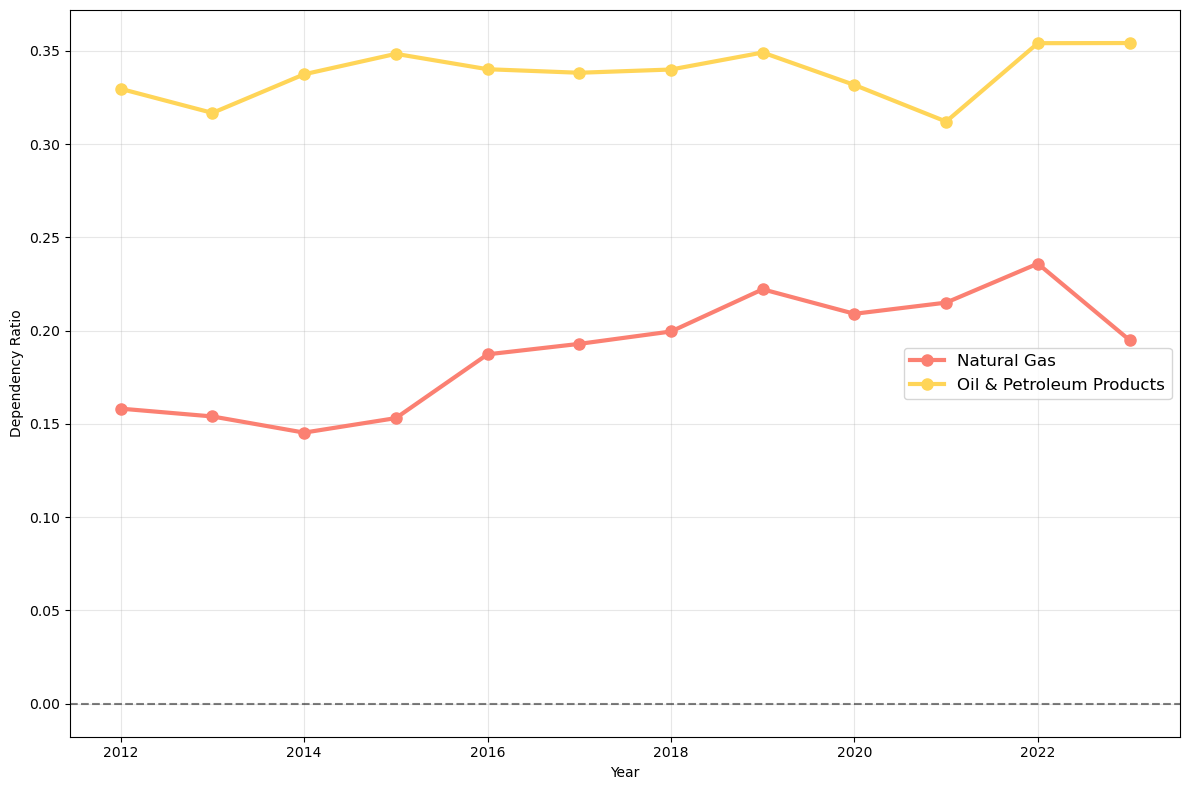

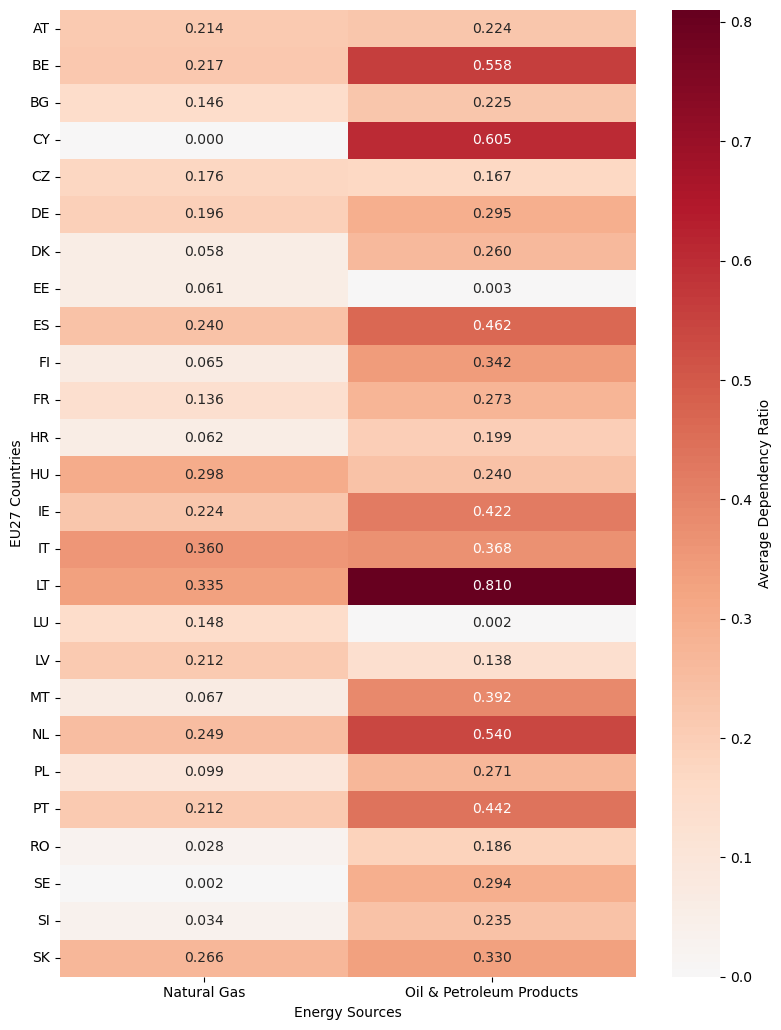

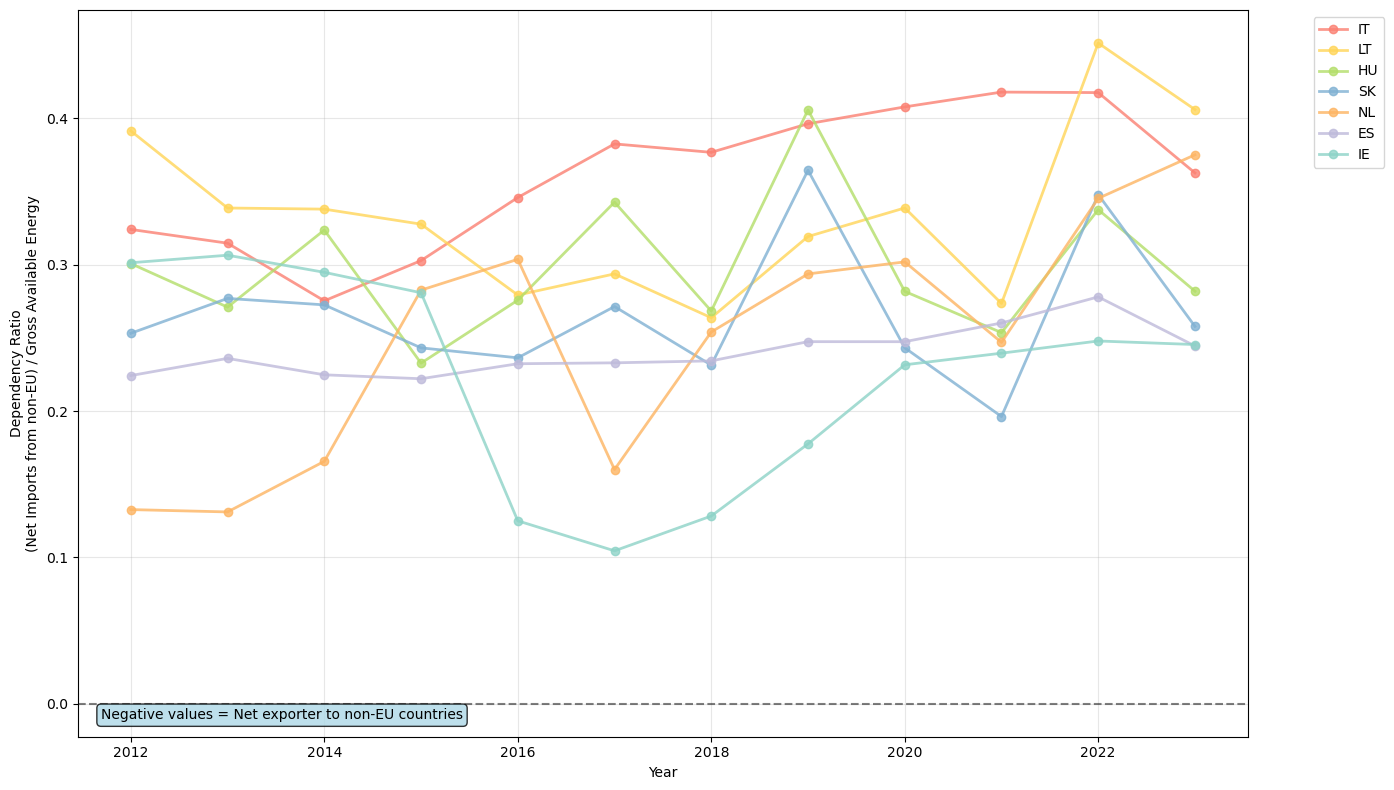

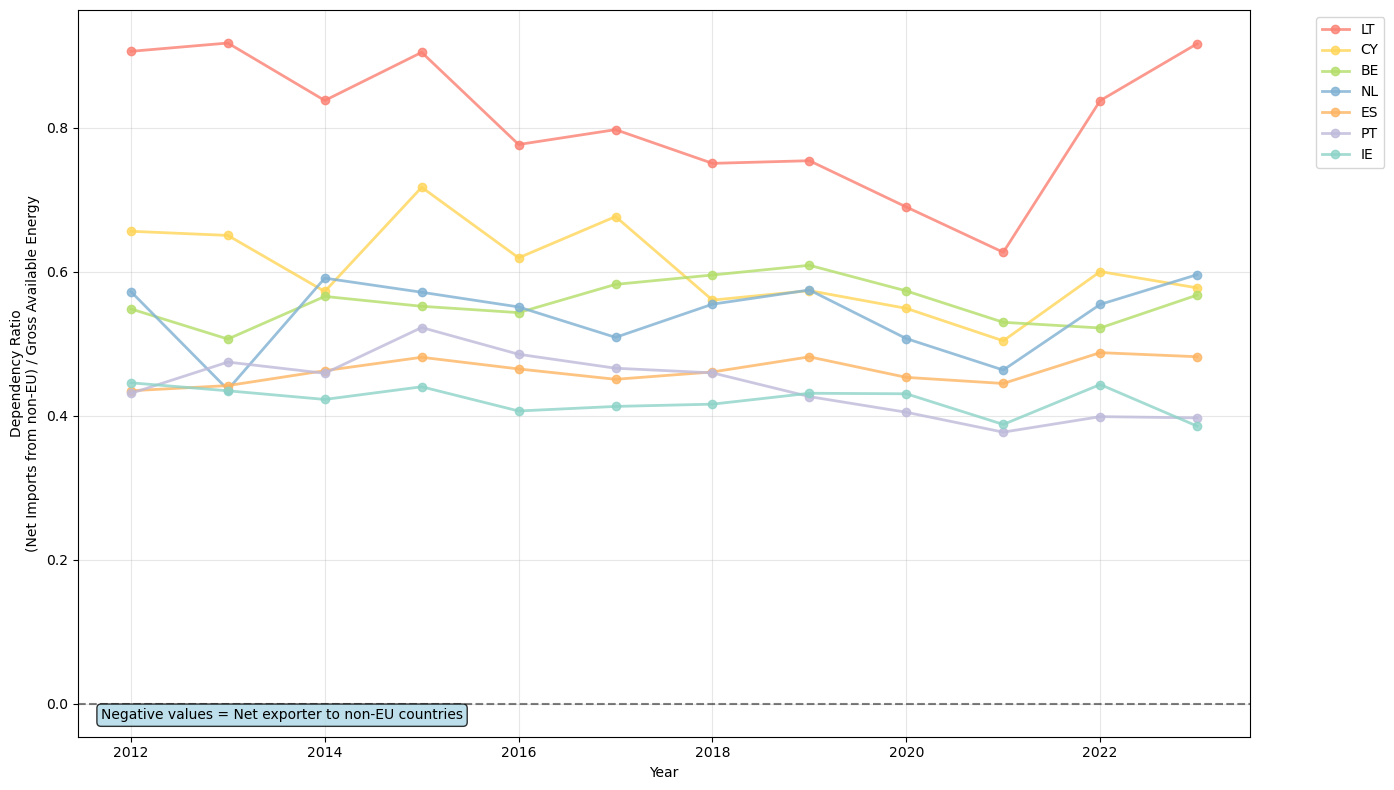

In [5]:
analyzer.plot_eu_dependency_trends()
analyzer.plot_country_dependency_heatmap()
analyzer.plot_country_dependency_timeseries()

## GDP

In [34]:
df_gdp = pd.read_csv(r'1_data_prep\indicator_economy\gdp_cp.csv')
df_final_energy = pd.read_csv(r'1_data_prep\indicator_energy\energy_use.csv')

In [25]:
study_countries = ['AT', 'BE', 'BG', 'HR','CY', 'CZ', 'DK', 'EE', 'FI',  
                   'FR', 'DE', 'GR', 'HU', 'IE', 'IT', 'LV', 'LT', 'LU', 
                   'MT', 'NL', 'PL', 'PT', 'RO', 'SK', 'SI', 'ES', 'SE', 
                   'UK', 'NO', 'CH', 'IS', 'LI']

In [26]:
df_gdp[df_gdp['geo'].isin(study_countries)]['geo'].unique()

array(['AT', 'BE', 'BG', 'CH', 'CY', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI',
       'FR', 'HR', 'HU', 'IE', 'IS', 'IT', 'LI', 'LT', 'LU', 'LV', 'MT',
       'NL', 'NO', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK', 'UK'], dtype=object)

In [28]:
df_gdp_EU = df_gdp[df_gdp['geo'].isin(study_countries)].groupby(['year'])['value'].sum().reset_index()
df_final_energy = df_final_energy[df_final_energy['geo'].isin(study_countries)].groupby(['year'])['value'].sum().reset_index()

In [35]:
df_final_energy[df_final_energy['geo']=='EU27_2020']

,Unnamed: 0,freq,nrg_bal,siec,unit,geo,year,value
12,12,A,FC_E,TOTAL,KTOE,EU27_2020,2012,934887.671
53,217,A,FC_E,TOTAL,KTOE,EU27_2020,2013,933240.704
94,422,A,FC_E,TOTAL,KTOE,EU27_2020,2014,891203.903
135,627,A,FC_E,TOTAL,KTOE,EU27_2020,2015,911325.264
176,832,A,FC_E,TOTAL,KTOE,EU27_2020,2016,929834.945
217,1037,A,FC_E,TOTAL,KTOE,EU27_2020,2017,942737.368
258,1242,A,FC_E,TOTAL,KTOE,EU27_2020,2018,944499.961
299,1447,A,FC_E,TOTAL,KTOE,EU27_2020,2019,939153.560
340,1652,A,FC_E,TOTAL,KTOE,EU27_2020,2020,886303.736
381,1857,A,FC_E,TOTAL,KTOE,EU27_2020,2021,940732.919


In [36]:
df_gdp_EU = df_gdp[df_gdp['geo']=='EU27_2020']
df_final_energy = df_final_energy[df_final_energy['geo']=='EU27_2020']

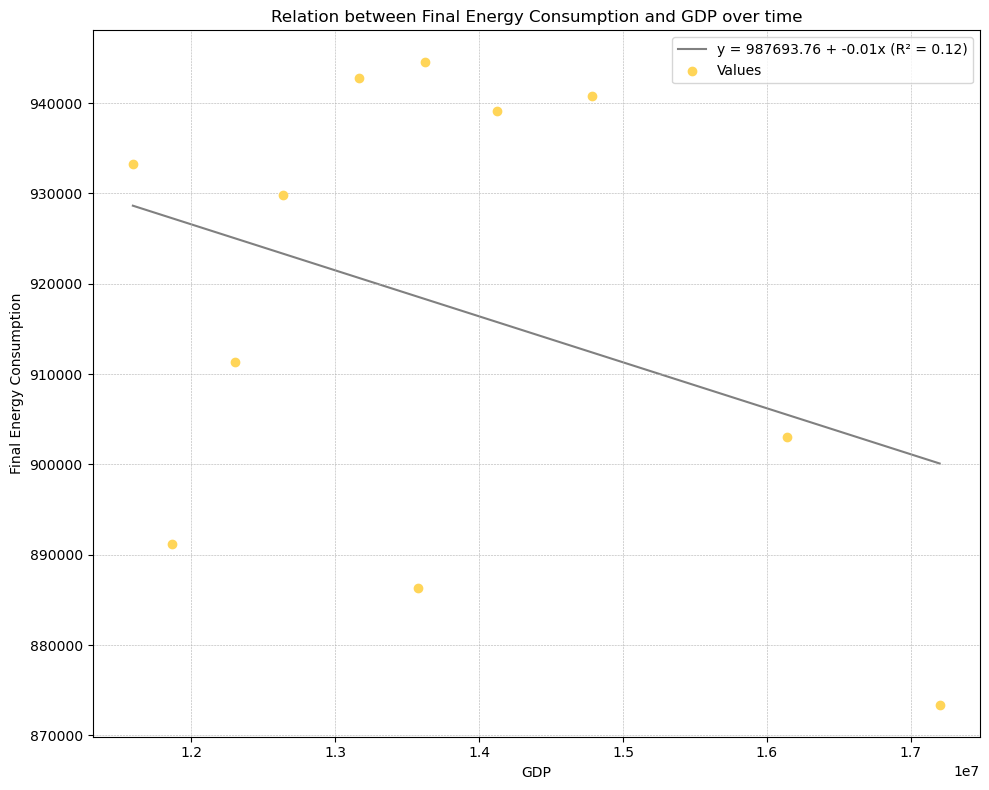

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Assuming df_gdp_EU and df_final_energy are already defined DataFrames
# Merge the two datasets on the 'year' column
df_merge = pd.merge(df_gdp_EU, df_final_energy, on='year', suffixes=('_gdp', '_energy'))

# Step 1: Drop rows with NaN in value_gdp or value_energy
df_clean = df_merge.dropna(subset=['value_gdp', 'value_energy'])

# Step 2: Perform linear regression
slope, intercept, r_value, _, _ = linregress(df_clean['value_gdp'], df_clean['value_energy'])

# Step 3: Compute regression line
x_vals = np.linspace(df_clean['value_gdp'].min(), df_clean['value_gdp'].max(), 200)
y_vals = intercept + slope * x_vals

# Step 4: Plot
plt.figure(figsize=(10, 8))

# Plot regression line first
plt.plot(x_vals, y_vals, '-', color='grey', linewidth=1.5,
         label=f'y = {intercept:.2f} + {slope:.2f}x (R² = {r_value**2:.2f})',
         zorder=1)

# Scatter points
plt.scatter(df_clean['value_gdp'], df_clean['value_energy'],
            c='#ffd558', marker='o', label='Values', zorder=2)

# Axis labels
plt.xlabel('GDP')
plt.ylabel('Final Energy Consumption')
plt.title('Relation between Final Energy Consumption and GDP over time')

# Grid, legend, layout
plt.grid(True, which='both', ls='--', linewidth=0.4)
plt.legend()
plt.tight_layout()
plt.show()


In [39]:
df_clean

,Unnamed: 0_gdp,freq_gdp,na_item,unit_gdp,geo_gdp,year,value_gdp,Unnamed: 0_energy,freq_energy,nrg_bal,siec,unit_energy,geo_energy,value_energy
0,55,A,B1GQ,CP_MEUR,EU27_2020,2013,11595087.4,217,A,FC_E,TOTAL,KTOE,EU27_2020,933240.704
1,138,A,B1GQ,CP_MEUR,EU27_2020,2014,11867906.9,422,A,FC_E,TOTAL,KTOE,EU27_2020,891203.903
2,221,A,B1GQ,CP_MEUR,EU27_2020,2015,12306819.5,627,A,FC_E,TOTAL,KTOE,EU27_2020,911325.264
3,304,A,B1GQ,CP_MEUR,EU27_2020,2016,12639176.9,832,A,FC_E,TOTAL,KTOE,EU27_2020,929834.945
4,387,A,B1GQ,CP_MEUR,EU27_2020,2017,13167374.7,1037,A,FC_E,TOTAL,KTOE,EU27_2020,942737.368
5,470,A,B1GQ,CP_MEUR,EU27_2020,2018,13627298.9,1242,A,FC_E,TOTAL,KTOE,EU27_2020,944499.961
6,553,A,B1GQ,CP_MEUR,EU27_2020,2019,14121912.9,1447,A,FC_E,TOTAL,KTOE,EU27_2020,939153.560
7,636,A,B1GQ,CP_MEUR,EU27_2020,2020,13579019.2,1652,A,FC_E,TOTAL,KTOE,EU27_2020,886303.736
8,719,A,B1GQ,CP_MEUR,EU27_2020,2021,14787713.6,1857,A,FC_E,TOTAL,KTOE,EU27_2020,940732.919
9,802,A,B1GQ,CP_MEUR,EU27_2020,2022,16136043.0,2062,A,FC_E,TOTAL,KTOE,EU27_2020,903034.404
